In [ ]:
!pip install catboost

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [87]:
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")
train = train.drop(columns=['id'])
train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [88]:
import numpy as np

# Convert 'TotalCharges' to numeric, coercing errors to NaN
train['TotalCharges'] = pd.to_numeric(train['TotalCharges'], errors='coerce')

# For customers with 0 tenure, TotalCharges should be 0
train.loc[train['tenure'] == 0, 'TotalCharges'] = 0

# Fill remaining NaN values in TotalCharges using MonthlyCharges * tenure
# Only apply where TotalCharges is still NaN and MonthlyCharges/tenure are not NaN
mask_fill = train['TotalCharges'].isna() & train['MonthlyCharges'].notna() & train['tenure'].notna()
train.loc[mask_fill, 'TotalCharges'] = train.loc[mask_fill, 'MonthlyCharges'] * train.loc[mask_fill, 'tenure']

# Fill any remaining NaNs in TotalCharges with the median of the column
# This handles cases where MonthlyCharges or tenure might have been NaN, or other edge cases
if train['TotalCharges'].isna().any():
    median_total_charges = train['TotalCharges'].median()
    train['TotalCharges'] = train['TotalCharges'].fillna(median_total_charges)

print("Missing values in 'TotalCharges' after imputation:")
print(train['TotalCharges'].isnull().sum())

print("First 5 rows of 'TotalCharges' after imputation:")
display(train['TotalCharges'].head())

Missing values in 'TotalCharges' after imputation:
0
First 5 rows of 'TotalCharges' after imputation:


,TotalCharges
0,1653.85
1,3778.20
2,5841.35
3,70.70
4,70.45


In [89]:
# Verify the changes by checking unique values and missing values again
print(f"Unique values for column 'TotalCharges' after handling NaNs:")
print(train['TotalCharges'].unique())
print(f"Number of NaN values in 'TotalCharges' after handling: {train['TotalCharges'].isna().sum()}")

Unique values for column 'TotalCharges' after handling NaNs:
[1653.85 3778.2  5841.35 ... 1478.9  1284.75 5460.7 ]
Number of NaN values in 'TotalCharges' after handling: 0


In [90]:
train['Churn'] = train['Churn'].astype(str).str.strip().str.capitalize().map({'Yes': 1, 'No': 0})
print(train['Churn'])

0         0
1         0
2         0
3         1
4         1
         ..
594189    0
594190    0
594191    0
594192    0
594193    1
Name: Churn, Length: 594194, dtype: int64


In [91]:
# Create has_internet flag
train['has_internet'] = (train['InternetService'] != 'No').astype(int)

# Create has_phone flag
train['has_phone'] = (train['PhoneService'] == 'Yes').astype(int)

# Create has_multiple_lines flag
train['has_multiple_lines'] = (train['MultipleLines'] == 'Yes').astype(int)

print("New flags created:")
display(train[['InternetService', 'has_internet', 'PhoneService', 'has_phone', 'MultipleLines', 'has_multiple_lines']].head())

New flags created:


,InternetService,has_internet,PhoneService,has_phone,MultipleLines,has_multiple_lines
0,DSL,1,Yes,1,No,0
1,DSL,1,Yes,1,No,0
2,Fiber optic,1,Yes,1,Yes,1
3,Fiber optic,1,Yes,1,No,0
4,Fiber optic,1,Yes,1,No,0


In [92]:
# List of value-added service columns
value_added_services = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# Define the mapping for these columns
service_mapping = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No i': 0}

# Apply the mapping to each column and convert to integer
for col in value_added_services:
    train[col] = train[col].astype(str).str.strip().str.capitalize().map(service_mapping).fillna(0).astype(int)

print("Value-added service columns transformed:")
display(train[value_added_services].head())

Value-added service columns transformed:


,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,1,0,1,1,0,0
1,1,1,0,1,1,0
2,0,1,0,0,1,1
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [93]:
# Create num_services_used by summing the transformed value-added service columns
train['num_services_used'] = train[value_added_services].sum(axis=1)

print("Number of services used per customer:")
display(train[['num_services_used'] + value_added_services].head())

Number of services used per customer:


,num_services_used,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,3,1,0,1,1,0,0
1,4,1,1,0,1,1,0
2,3,0,1,0,0,1,1
3,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0


In [94]:
print("Unique values for 'num_services_used':")
print(train['num_services_used'].unique())
print("Value counts for 'num_services_used':")
display(train['num_services_used'].value_counts())

Unique values for 'num_services_used':
[3 4 0 6 1 5 2]
Value counts for 'num_services_used':


,count
num_services_used,
0,203853
2,81929
3,79585
1,75363
4,64692
5,49277
6,39495


In [95]:
# Create tenure_buckets
bins = [-1, 12, 36, train['tenure'].max()]
labels = ['new', 'mid', 'loyal']
train['tenure_buckets'] = pd.cut(train['tenure'], bins=bins, labels=labels, right=True)

# Calculate avg_charge, handling potential division by zero
# If tenure is 0, TotalCharges is also 0, so avg_charge should be 0
train['avg_charge'] = np.where(train['tenure'] == 0, 0, train['TotalCharges'] / train['tenure'])

print("New features 'tenure_buckets' and 'avg_charge' created:")
display(train[['tenure', 'tenure_buckets', 'TotalCharges', 'avg_charge']].head())

New features 'tenure_buckets' and 'avg_charge' created:


,tenure,tenure_buckets,TotalCharges,avg_charge
0,29,mid,1653.85,57.029310
1,58,loyal,3778.20,65.141379
2,58,loyal,5841.35,100.712931
3,1,new,70.70,70.700000
4,1,new,70.45,70.450000


In [96]:
print("Unique values for 'tenure_buckets':")
print(train['tenure_buckets'].unique())
print("Value counts for 'tenure_buckets':")
display(train['tenure_buckets'].value_counts())

print("Check for infinite or NaN values in 'avg_charge':")
print(f"NaNs in avg_charge: {train['avg_charge'].isnull().sum()}")
print(f"Infs in avg_charge: {np.isinf(train['avg_charge']).sum()}")

Unique values for 'tenure_buckets':
['mid', 'loyal', 'new']
Categories (3, object): ['new' < 'mid' < 'loyal']
Value counts for 'tenure_buckets':


,count
tenure_buckets,
loyal,289349
new,152646
mid,152199


Check for infinite or NaN values in 'avg_charge':
NaNs in avg_charge: 0
Infs in avg_charge: 0


In [97]:
for col in train.columns:
    print(f"Unique values for column '{col}':")
    print(train[col].unique())
    print("\n")

Unique values for column 'gender':
['Male' 'Female']


Unique values for column 'SeniorCitizen':
[0 1]


Unique values for column 'Partner':
['Yes' 'No']


Unique values for column 'Dependents':
['Yes' 'No']


Unique values for column 'tenure':
[29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32]


Unique values for column 'PhoneService':
['Yes' 'No']


Unique values for column 'MultipleLines':
['No' 'Yes' 'No phone service']


Unique values for column 'InternetService':
['DSL' 'Fiber optic' 'No']


Unique values for column 'OnlineSecurity':
[1 0]


Unique values for column 'OnlineBackup':
[0 1]


Unique values for column 'DeviceProtection':
[1 0]


Unique values for column 'TechSupport':
[1 0]


Unique values for column 'StreamingTV':
[0 1]


Unique values for column 'StreamingMovies':
[0 1]


Unique values for column 'C

In [98]:
for col in train.columns:
    if train[col].hasnans:
        print(f"Column '{col}' has missing values.")

In [99]:
train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'has_internet', 'has_phone',
       'has_multiple_lines', 'num_services_used', 'tenure_buckets',
       'avg_charge'],
      dtype='object')

In [100]:
train['Churn_Numeric'] = train['Churn']

print("Churn_Numeric column status:")
display(train[['Churn', 'Churn_Numeric']].head())

Churn_Numeric column status:


,Churn,Churn_Numeric
0,0,0
1,0,0
2,0,0
3,1,1
4,1,1


### Combined Churn Percentage by Contract, PaperlessBilling, and PaymentMethod

In [101]:
combined_churn = train.groupby(['Contract', 'PaperlessBilling', 'PaymentMethod'])['Churn_Numeric'].mean().reset_index()
combined_churn['Churn_Percentage'] = combined_churn['Churn_Numeric'] * 100
print("Churn Percentage for combined factors:")
display(combined_churn.sort_values('Churn_Percentage', ascending=False).head(20)) # Display top 20 combinations by churn percentage

Churn Percentage for combined factors:


,Contract,PaperlessBilling,PaymentMethod,Churn_Numeric,Churn_Percentage
6,Month-to-month,Yes,Electronic check,0.583303,58.330350
2,Month-to-month,No,Electronic check,0.395830,39.583010
4,Month-to-month,Yes,Bank transfer (automatic),0.277967,27.796699
5,Month-to-month,Yes,Credit card (automatic),0.271386,27.138578
7,Month-to-month,Yes,Mailed check,0.254289,25.428880
14,One year,Yes,Electronic check,0.165719,16.571906
1,Month-to-month,No,Credit card (automatic),0.138083,13.808287
0,Month-to-month,No,Bank transfer (automatic),0.137710,13.770960
3,Month-to-month,No,Mailed check,0.104195,10.419481
10,One year,No,Electronic check,0.074736,7.473599


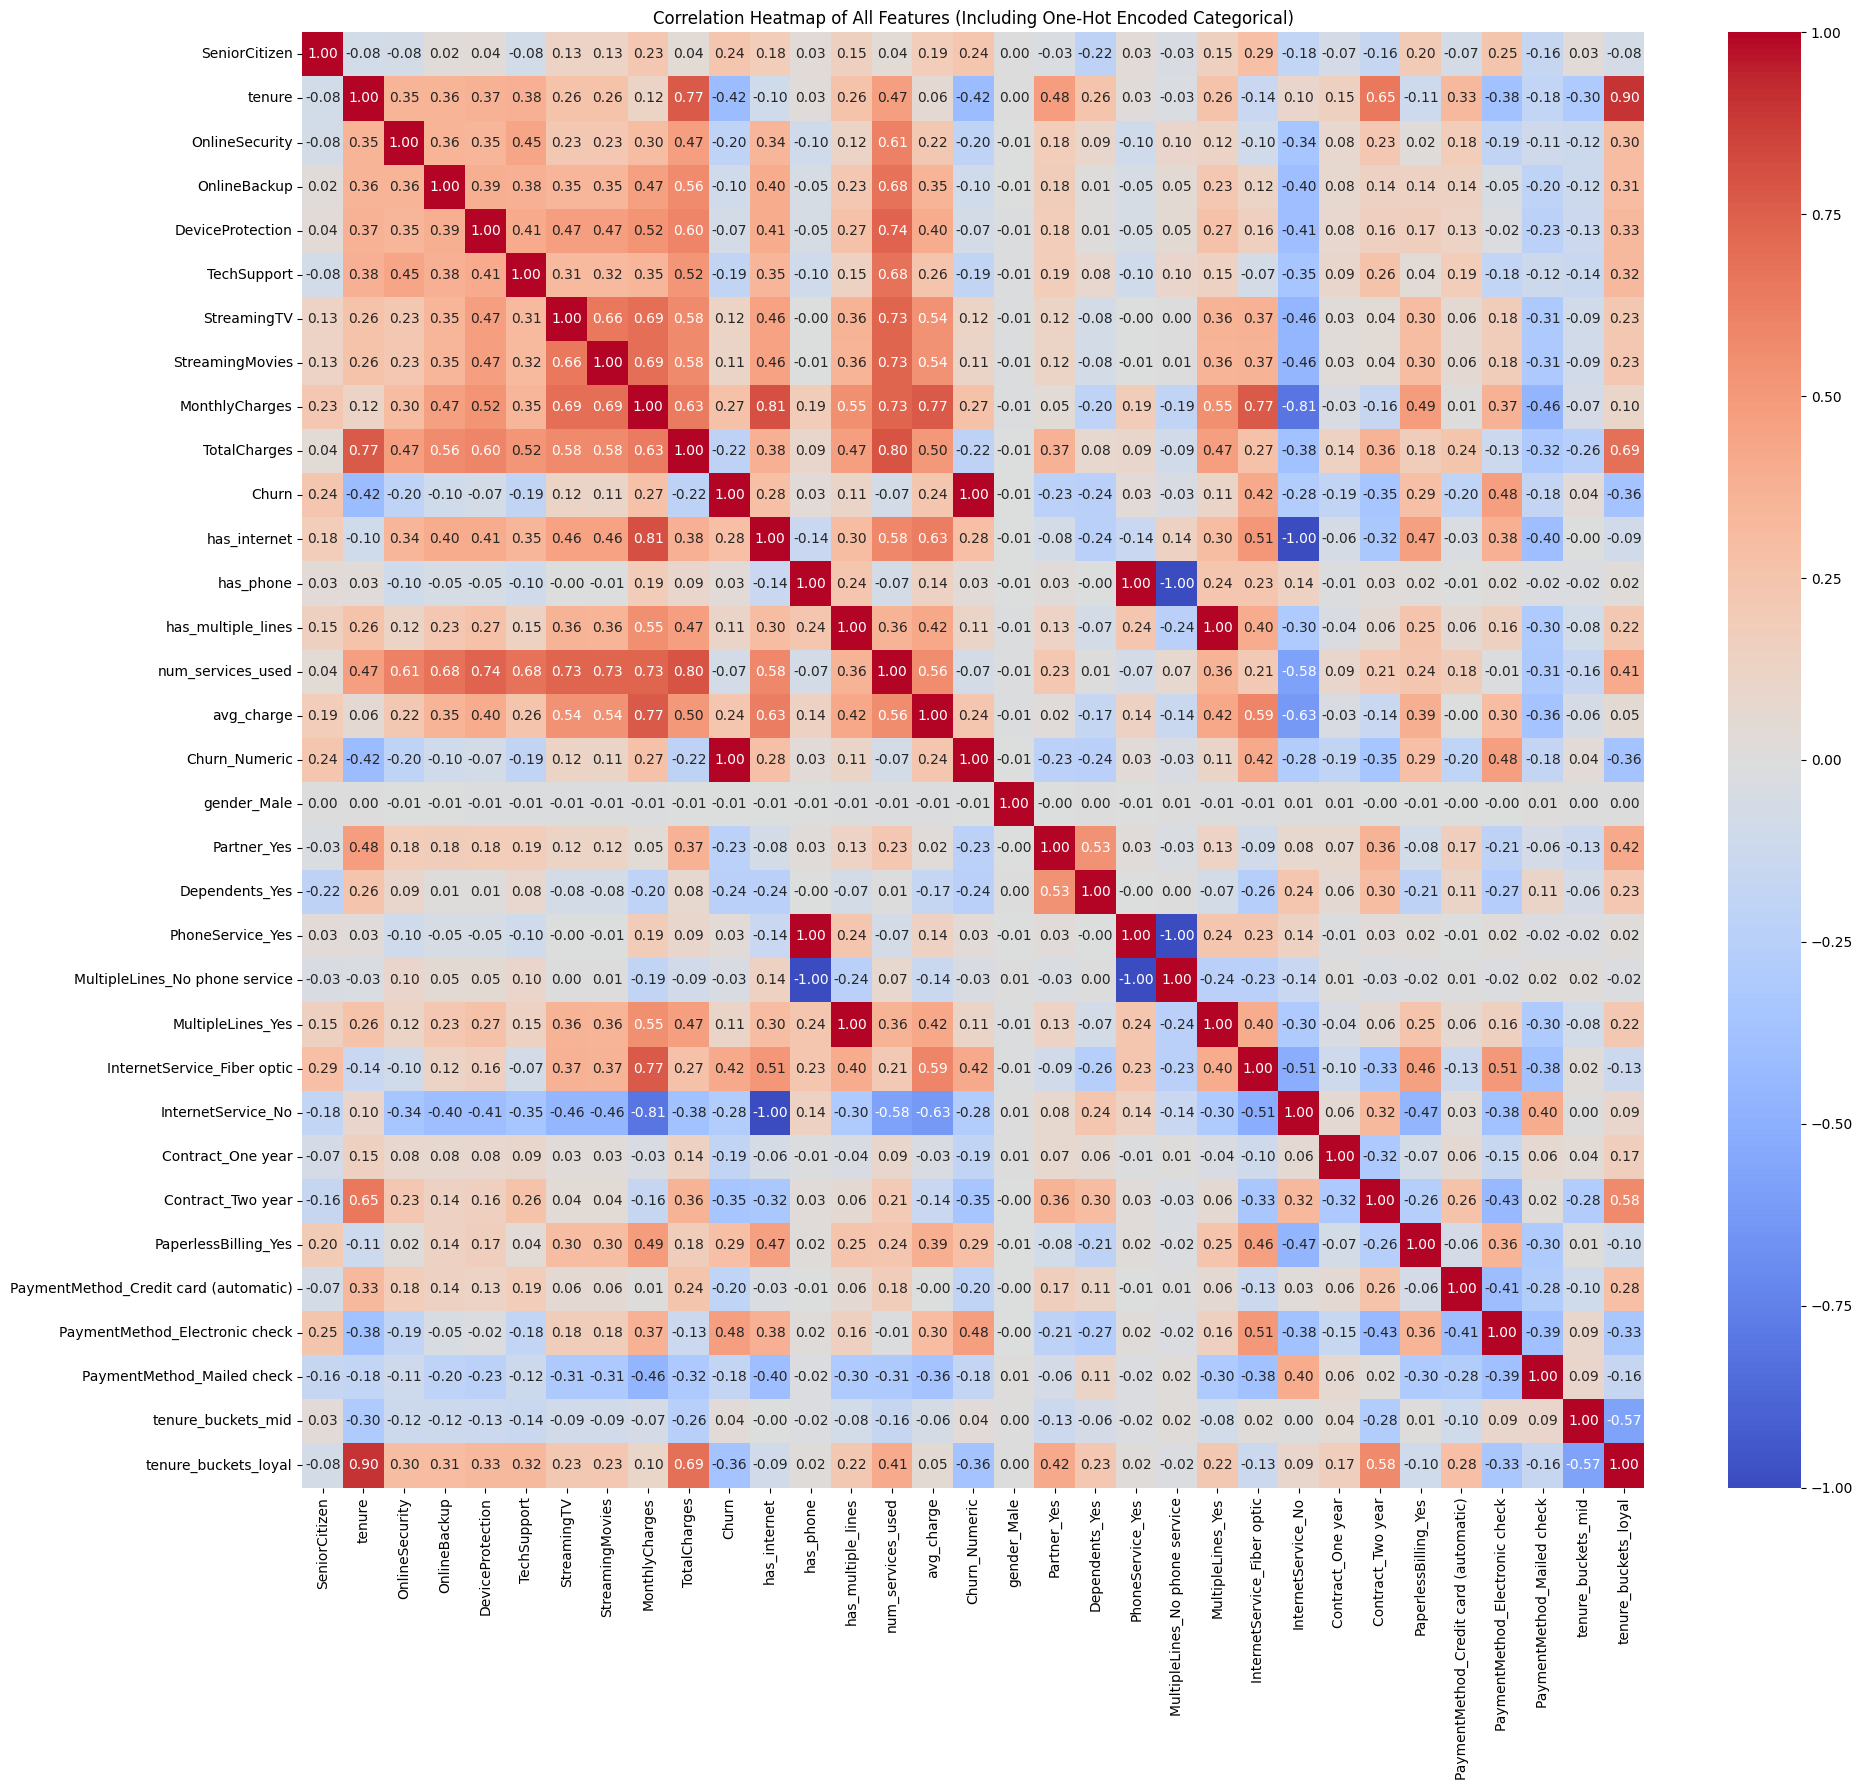

In [102]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN, and fill NaNs
train['TotalCharges'] = pd.to_numeric(train['TotalCharges'], errors='coerce')



# Drop 'id' column if it still exists and was not dropped previously
df_processed = train.drop(columns=['id'], errors='ignore')

# Separate numerical and categorical columns
numerical_cols = df_processed.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df_processed.select_dtypes(exclude=['number']).columns.tolist()

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Recalculate correlation matrix for the fully processed DataFrame
correlation_matrix_all = df_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(20, 18)) # Adjust figure size for many features
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f") # Annot=False for readability with many features
plt.title('Correlation Heatmap of All Features (Including One-Hot Encoded Categorical)')
plt.tight_layout()
plt.show()

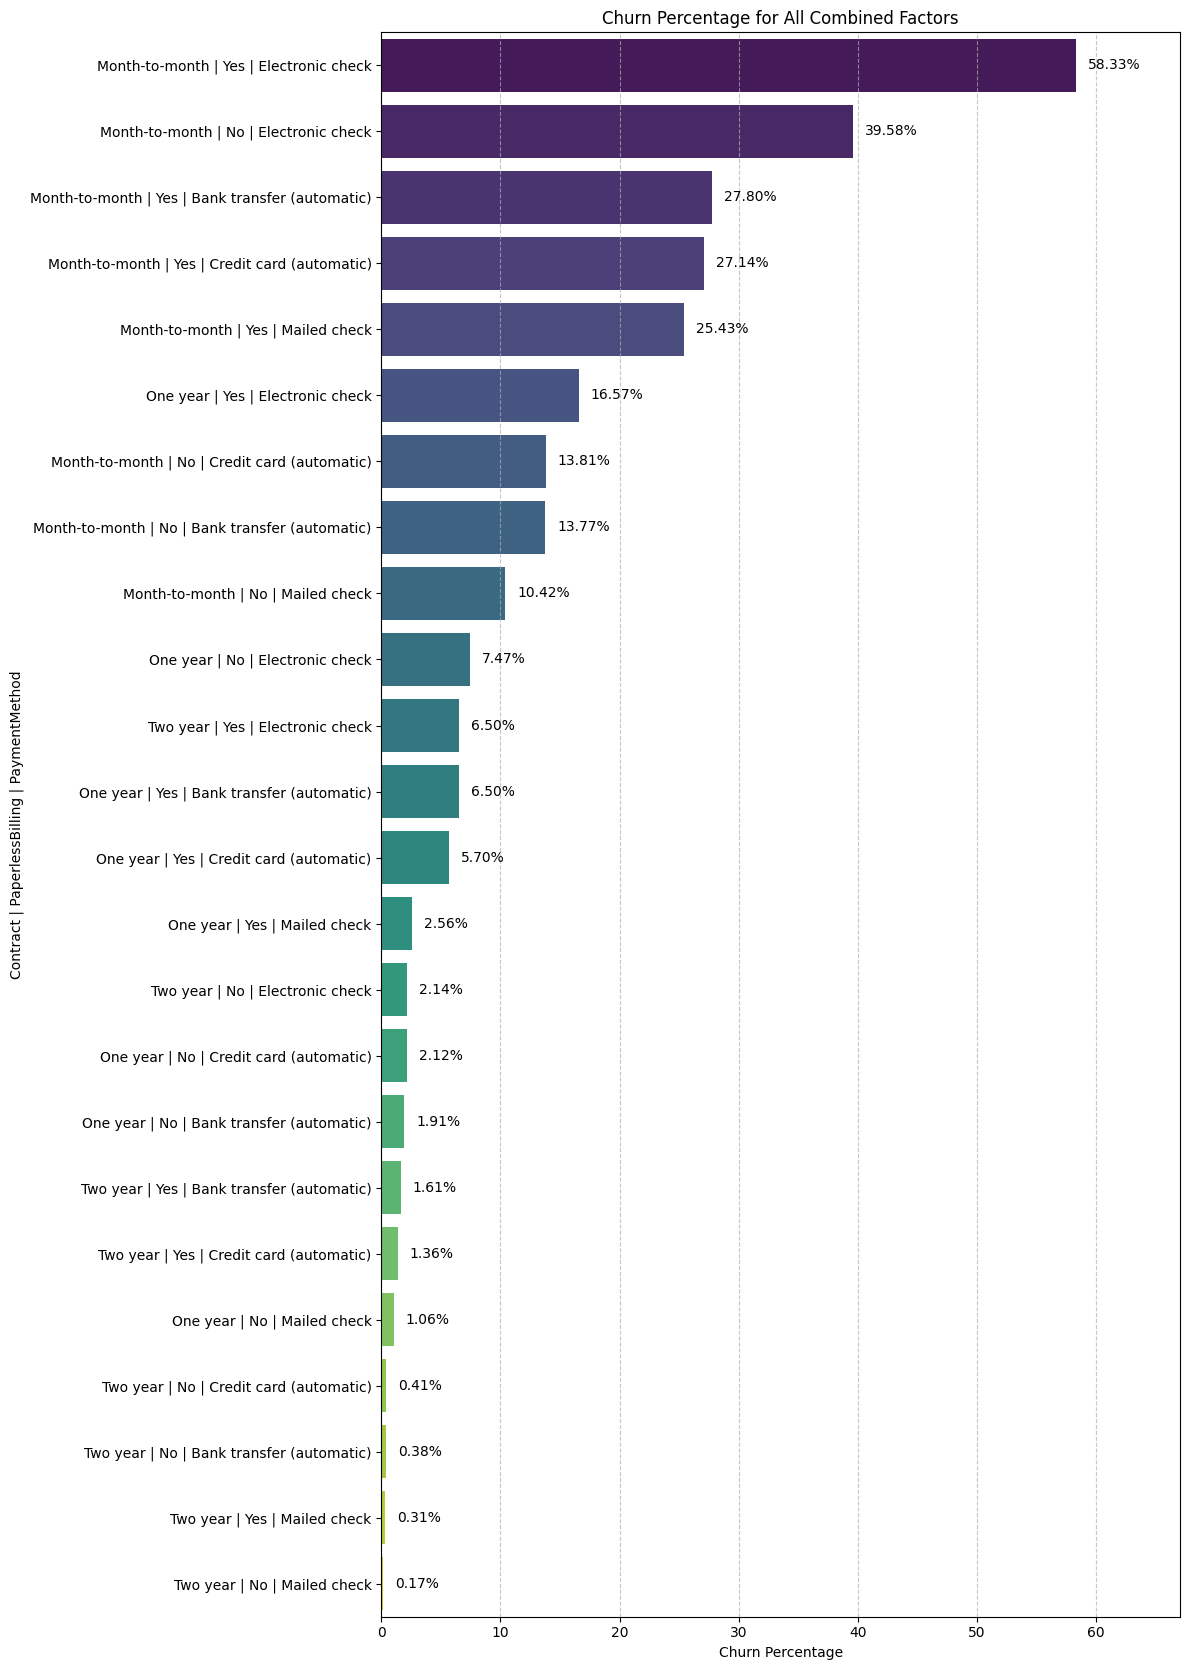

In [103]:
# Use all combined_churn data, sorted
combined_churn_sorted = combined_churn.sort_values('Churn_Percentage', ascending=False)

# Create a combined category column for plotting
combined_churn_sorted['Combined_Category'] = combined_churn_sorted['Contract'] + ' | ' + \
                                            combined_churn_sorted['PaperlessBilling'] + ' | ' + \
                                            combined_churn_sorted['PaymentMethod']

# Adjust figure size dynamically based on the number of categories
num_categories = len(combined_churn_sorted)
fig_height = max(7, num_categories * 0.7) # Minimum height of 7, then 0.7 units per category
plt.figure(figsize=(12, fig_height))

ax = sns.barplot(x='Churn_Percentage', y='Combined_Category', hue='Combined_Category', data=combined_churn_sorted, palette='viridis', legend=False)
plt.xlabel('Churn Percentage')
plt.ylabel('Contract | PaperlessBilling | PaymentMethod')
plt.title('Churn Percentage for All Combined Factors')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add percentage labels on the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 1, p.get_y() + p.get_height() / 2,    # Set position for the text
             '{:1.2f}%'.format(width),                      # Format the text to 2 decimal places with a '%' sign
             ha = 'left', va = 'center')                     # Horizontal alignment to left, vertical alignment to center

plt.xlim(0, combined_churn_sorted['Churn_Percentage'].max() * 1.15) # Adjust x-axis limit to make space for labels
plt.tight_layout()
plt.show()

In [104]:
combined_churn_sorted.head()

,Contract,PaperlessBilling,PaymentMethod,Churn_Numeric,Churn_Percentage,Combined_Category
6,Month-to-month,Yes,Electronic check,0.583303,58.330350,Month-to-month | Yes | Electronic check
2,Month-to-month,No,Electronic check,0.395830,39.583010,Month-to-month | No | Electronic check
4,Month-to-month,Yes,Bank transfer (automatic),0.277967,27.796699,Month-to-month | Yes | Bank transfer (automatic)
5,Month-to-month,Yes,Credit card (automatic),0.271386,27.138578,Month-to-month | Yes | Credit card (automatic)
7,Month-to-month,Yes,Mailed check,0.254289,25.428880,Month-to-month | Yes | Mailed check


In [105]:
# Create a combined key in the 'train' DataFrame
train['combined_key'] = train['Contract'].astype(str) + '_' + \
                         train['PaperlessBilling'].astype(str) + '_' + \
                         train['PaymentMethod'].astype(str)

# Create a combined key in the 'combined_churn' DataFrame for merging
combined_churn['combined_key'] = combined_churn['Contract'].astype(str) + '_' + \
                                  combined_churn['PaperlessBilling'].astype(str) + '_' + \
                                  combined_churn['PaymentMethod'].astype(str)

# Create the 'risk_profile' by mapping the churn percentage back to the train DataFrame
# We will merge on the 'combined_key' to get the 'Churn_Percentage'
train = pd.merge(train, combined_churn[['combined_key', 'Churn_Percentage']], on='combined_key', how='left')

# Rename the Churn_Percentage column to risk_profile
train = train.rename(columns={'Churn_Percentage': 'risk_profile'})

# Drop the temporary combined_key columns
train = train.drop(columns=['combined_key'])

print("New 'risk_profile' feature created based on Contract, PaperlessBilling, and PaymentMethod:")
display(train[['Contract', 'PaperlessBilling', 'PaymentMethod', 'risk_profile', 'Churn']].head())

New 'risk_profile' feature created based on Contract, PaperlessBilling, and PaymentMethod:


,Contract,PaperlessBilling,PaymentMethod,risk_profile,Churn
0,One year,Yes,Mailed check,2.563418,0
1,Two year,No,Credit card (automatic),0.409814,0
2,Month-to-month,Yes,Electronic check,58.330350,0
3,Month-to-month,Yes,Electronic check,58.330350,1
4,Month-to-month,Yes,Electronic check,58.330350,1


In [106]:
print("Check for any NaN values in the new 'risk_profile' feature:")
print(train['risk_profile'].isnull().sum())

print("Value counts for 'risk_profile' (top 10 unique values):")
display(train['risk_profile'].value_counts())

Check for any NaN values in the new 'risk_profile' feature:
0
Value counts for 'risk_profile' (top 10 unique values):


,count
risk_profile,
58.330350,156416
0.409814,37578
1.359653,34347
0.379853,33434
0.172330,33076
1.614040,29801
10.419481,28869
39.583010,25756
25.428880,25007


In [107]:
train.drop(columns=['Churn_Numeric'])

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,has_internet,has_phone,has_multiple_lines,num_services_used,tenure_buckets,avg_charge,risk_profile
0,Male,0,Yes,Yes,29,Yes,No,DSL,1,0,...,60.10,1653.85,0,1,1,0,3,mid,57.029310,2.563418
1,Male,0,Yes,Yes,58,Yes,No,DSL,1,1,...,69.50,3778.20,0,1,1,0,4,loyal,65.141379,0.409814
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,0,1,...,100.40,5841.35,0,1,1,1,3,loyal,100.712931,58.330350
3,Female,0,No,No,1,Yes,No,Fiber optic,0,0,...,69.70,70.70,1,1,1,0,0,new,70.700000,58.330350
4,Female,0,No,No,1,Yes,No,Fiber optic,0,0,...,70.45,70.45,1,1,1,0,0,new,70.450000,58.330350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,0,0,...,97.55,5460.70,0,1,1,1,3,loyal,95.801754,0.379853
594190,Female,0,No,No,72,Yes,Yes,DSL,1,1,...,91.95,6782.15,0,1,1,1,6,loyal,94.196528,0.379853
594191,Female,0,Yes,No,72,Yes,Yes,No,0,0,...,24.40,1871.90,0,0,1,1,0,loyal,25.998611,0.409814
594192,Female,0,No,No,32,Yes,Yes,Fiber optic,0,0,...,86.00,2847.20,0,1,1,1,1,mid,88.975000,58.330350


In [108]:
for col in train.columns:
    print(f"Unique values for column '{col}':")
    print(train[col].unique())
    print("\n")

Unique values for column 'gender':
['Male' 'Female']


Unique values for column 'SeniorCitizen':
[0 1]


Unique values for column 'Partner':
['Yes' 'No']


Unique values for column 'Dependents':
['Yes' 'No']


Unique values for column 'tenure':
[29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32]


Unique values for column 'PhoneService':
['Yes' 'No']


Unique values for column 'MultipleLines':
['No' 'Yes' 'No phone service']


Unique values for column 'InternetService':
['DSL' 'Fiber optic' 'No']


Unique values for column 'OnlineSecurity':
[1 0]


Unique values for column 'OnlineBackup':
[0 1]


Unique values for column 'DeviceProtection':
[1 0]


Unique values for column 'TechSupport':
[1 0]


Unique values for column 'StreamingTV':
[0 1]


Unique values for column 'StreamingMovies':
[0 1]


Unique values for column 'C

In [119]:
train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'has_internet', 'has_phone',
       'has_multiple_lines', 'num_services_used', 'tenure_buckets',
       'avg_charge', 'Churn_Numeric', 'risk_profile'],
      dtype='object')

### Baseline

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from catboost import CatBoostClassifier

In [118]:
#recreate risk profile as it was data leakage previously

train.drop(columns=['risk_profile'])

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,has_internet,has_phone,has_multiple_lines,num_services_used,tenure_buckets,avg_charge,Churn_Numeric
0,Male,0,Yes,Yes,29,Yes,No,DSL,1,0,...,60.10,1653.85,0,1,1,0,3,mid,57.029310,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,1,1,...,69.50,3778.20,0,1,1,0,4,loyal,65.141379,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,0,1,...,100.40,5841.35,0,1,1,1,3,loyal,100.712931,0
3,Female,0,No,No,1,Yes,No,Fiber optic,0,0,...,69.70,70.70,1,1,1,0,0,new,70.700000,1
4,Female,0,No,No,1,Yes,No,Fiber optic,0,0,...,70.45,70.45,1,1,1,0,0,new,70.450000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,0,0,...,97.55,5460.70,0,1,1,1,3,loyal,95.801754,0
594190,Female,0,No,No,72,Yes,Yes,DSL,1,1,...,91.95,6782.15,0,1,1,1,6,loyal,94.196528,0
594191,Female,0,Yes,No,72,Yes,Yes,No,0,0,...,24.40,1871.90,0,0,1,1,0,loyal,25.998611,0
594192,Female,0,No,No,32,Yes,Yes,Fiber optic,0,0,...,86.00,2847.20,0,1,1,1,1,mid,88.975000,0


In [120]:

train['risk_profile'] = (
    train['Contract'].astype(str) + '_' +
    train['PaperlessBilling'].astype(str) + '_' +
    train['PaymentMethod'].astype(str)
)

# Do the same for test data
test['risk_profile'] = (
    test['Contract'].astype(str) + '_' +
    test['PaperlessBilling'].astype(str) + '_' +
    test['PaymentMethod'].astype(str)
)

# Quick sanity check
print("Unique risk profiles:", train['risk_profile'].nunique())
print(train['risk_profile'].head())

Unique risk profiles: 24
0              One year_Yes_Mailed check
1    Two year_No_Credit card (automatic)
2    Month-to-month_Yes_Electronic check
3    Month-to-month_Yes_Electronic check
4    Month-to-month_Yes_Electronic check
Name: risk_profile, dtype: object


In [124]:
# Target
target = 'Churn'

# Columns to DROP
drop_cols = ['id', 'Churn', 'Churn_Numeric']  # remove leakage + id

# Feature columns
features = [col for col in train.columns if col not in drop_cols]

# Separate X and y
X = train[features]
y = train[target]

In [126]:
cat_features = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'tenure_buckets',
    'risk_profile'
]

In [127]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [128]:
model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    l2_leaf_reg=3,
    early_stopping_rounds=100,
    verbose=100
)

In [129]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val)
)

0:	test: 0.8884188	best: 0.8884188 (0)	total: 1.92s	remaining: 31m 59s
100:	test: 0.9134680	best: 0.9134680 (100)	total: 1m 36s	remaining: 14m 17s
200:	test: 0.9147409	best: 0.9147409 (200)	total: 2m 53s	remaining: 11m 29s
300:	test: 0.9153881	best: 0.9153881 (300)	total: 4m 14s	remaining: 9m 50s
400:	test: 0.9158287	best: 0.9158287 (400)	total: 5m 34s	remaining: 8m 19s
500:	test: 0.9161023	best: 0.9161023 (500)	total: 6m 56s	remaining: 6m 54s
600:	test: 0.9162860	best: 0.9162870 (596)	total: 8m 16s	remaining: 5m 29s
700:	test: 0.9164252	best: 0.9164252 (700)	total: 9m 48s	remaining: 4m 11s
800:	test: 0.9165343	best: 0.9165343 (800)	total: 11m 14s	remaining: 2m 47s
900:	test: 0.9166026	best: 0.9166026 (898)	total: 12m 49s	remaining: 1m 24s
999:	test: 0.9166764	best: 0.9166764 (999)	total: 14m 23s	remaining: 0us

bestTest = 0.9166764446
bestIteration = 999



CatBoostClassifier(depth=6, early_stopping_rounds=100, eval_metric='AUC', iterations=1000, l2_leaf_reg=3, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [130]:
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred_proba)

print("Validation AUC:", auc)

Validation AUC: 0.9166764445689393


In [133]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'has_internet', 'has_phone',
       'has_multiple_lines', 'num_services_used', 'tenure_buckets',
       'avg_charge', 'risk_profile'],
      dtype='object')

In [134]:
y

,Churn
0,0
1,0
2,0
3,1
4,1
...,...
594189,0
594190,0
594191,0
594192,0


In [168]:
test = pd.read_csv("/content/test (1).csv")

In [169]:
test.shape

(254655, 20)

In [170]:
print(set(X.columns) - set(test.columns))
print(set(test.columns) - set(X.columns))

{'has_multiple_lines', 'num_services_used', 'tenure_buckets', 'risk_profile', 'avg_charge', 'has_phone', 'has_internet'}
{'id'}


In [171]:
test['risk_profile'] = (
    test['Contract'].astype(str) + '_' +
    test['PaperlessBilling'].astype(str) + '_' +
    test['PaymentMethod'].astype(str)
)

In [172]:
for col in cat_features:
    if col not in test.columns:
        print(col, "missing in test")

tenure_buckets missing in test


In [173]:
# has_internet
test['has_internet'] = (test['InternetService'] != 'No').astype(int)

# has_phone
test['has_phone'] = (test['PhoneService'] == 'Yes').astype(int)

# has_multiple_lines
test['has_multiple_lines'] = (test['MultipleLines'] == 'Yes').astype(int)

In [174]:
services = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in services:
    test[col] = test[col].replace({
        'Yes': 1,
        'No': 0,
        'No internet service': 0,
        'No i': 0
    })

/tmp/ipykernel_1113/2514501221.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test[col] = test[col].replace({


In [175]:
test.shape

(254655, 24)

In [177]:
test['num_services_used'] = test[services].sum(axis=1)

In [176]:
def tenure_bucket(x):
    if x <= 12:
        return 'new'
    elif x <= 36:
        return 'mid'
    else:
        return 'loyal'

test['tenure_buckets'] = test['tenure'].apply(tenure_bucket)

In [178]:
test['TotalCharges'] = pd.to_numeric(test['TotalCharges'], errors='coerce')
test['TotalCharges'] = test['TotalCharges'].fillna(test['TotalCharges'].median())

test['avg_charge'] = test['TotalCharges'] / test['tenure'].replace(0, 1)

In [179]:
X_test = test[X.columns]

In [180]:
print(set(X.columns) - set(test.columns))
print(set(test.columns) - set(X.columns))

set()
{'id'}


In [181]:
X_test = test[X.columns]

for col in cat_features:
    if col in X_test.columns:
        # Fill NaN values with a placeholder string and ensure the column is of string type.
        X_test.loc[:, col] = X_test[col].fillna('Unknown').astype(str)

preds = model.predict_proba(X_test)[:, 1]

In [182]:
print(X_test.shape)

(254655, 26)


In [183]:
# Create submission
submission = pd.DataFrame({
    'id': test['id'],
    'Churn': preds
})

submission.to_csv('submission.csv', index=False)
print("✅ Submission ready!")

✅ Submission ready!
